## Fokus Bab

Bab ini berfokus pada analisis variabel categorical secara individual — melengkapi Bab 02 yang membahas variabel numerik. Fokus utamanya adalah memahami distribusi frekuensi kategori, mengidentifikasi kategori yang dominan maupun langka, serta menilai kardinalitas suatu variabel kategorikal sebagai pertimbangan penting sebelum tahap encoding pada fase modeling.

## Tujuan Pembelajaran

* Menghitung dan menginterpretasikan frekuensi absolut maupun relatif dari suatu variabel kategorikal
* Mengidentifikasi kategori dominan dan kategori langka (rare category) dalam suatu distribusi
* Menilai kardinalitas suatu variabel kategorikal dan memahami implikasinya terhadap strategi encoding
* Memvisualisasikan distribusi kategori menggunakan count plot, serta memilih antara representasi frekuensi absolut atau relatif sesuai konteks analisis

## Isi Materi

1. Frequency Analysis — frequency count, value_counts(), relative frequency
2. Category Distribution — dominant category, rare category, cardinality, distribution shape
3. Categorical Visualization — count plot, perbandingan frekuensi absolut vs relatif

## Goals

Mampu menjawab pertanyaan: "Kategori apa yang dominan, langka, atau berpotensi bermasalah untuk encoding, pada setiap variabel kategorikal dalam dataset ini?"

## Referensi / sumber materi

* Pandas User Guide — Series.value_counts()
* Seaborn documentation — seaborn.countplot
* Scikit-learn User Guide — Encoding categorical features (rujukan kontekstual untuk implikasi cardinality)

# 1. Frequency Analysis

* Variabel kategorikal dianalisis melalui seberapa sering setiap kategori muncul dalam dataset

## 1.1 Frequency Count

* Frequency count: jumlah kemmunculan mentah (raw count) dari setiap nilai unik pada suatu kolom kategorikal.
* seluruh konsep pada bab ini (dominan, langka, kardinalitas) diturunkan dari frequency count.
* Frequency count menjawab pertanyaan sederhana: "Berapa kali setiap kategori muncul?"
* Frequency count berbeda dari frekuensi relatif, yang menyatakan proporsi terhadap total observasi

In [1]:
import pandas as pd
import numpy as np

In [2]:
#------------------------------------------------------------------
# Dataset sintetis: Data Karyawan Perusahaan Manufaktur
# Anggap ini adalah output Fase 1 (cleaning) yang akan Anda VERIFIKASI
# di Modul 01 — bukan dataset yang sudah pasti 100% bersih.
# ------------------------------------------------------------------

np.random.seed(42)  # supaya hasil random selalu sama tiap dijalankan

n = 200  # jumlah baris

# --- Kolom identifier ---
employee_id = list(range(1001, 1001 + n))

# --- Kolom numerical ---
usia = np.random.randint(21, 58, size=n).astype(float)
gaji = np.random.randint(4_000_000, 15_000_000, size=n)
lama_bekerja_bulan = np.random.randint(1, 120, size=n)

# --- Kolom categorical ---
departemen = np.random.choice(
    ['Produksi', 'Quality Control', 'Logistik', 'HR', 'Finance'],
    size=n, p=[0.4, 0.2, 0.2, 0.1, 0.1]  # sengaja tidak merata → cardinality realistis
)
status_karyawan = np.random.choice(['Aktif', 'Resign'], size=n, p=[0.85, 0.15])
level_pendidikan = np.random.choice(
    ['SMA', 'D3', 'S1', 'S2'], size=n, p=[0.3, 0.2, 0.4, 0.1]
)

# --- Kolom datetime, SENGAJA dibuat sebagai string dengan format campuran ---
tanggal_masuk = pd.date_range('2015-01-01', '2024-01-01', periods=n).strftime('%Y-%m-%d').tolist()

# --- Gaji, SENGAJA diberi format string dengan simbol supaya jadi 'object' ---
gaji_str = ['Rp' + format(g, ',').replace(',', '.') for g in gaji]

df = pd.DataFrame({
    'employee_id': employee_id,
    'usia': usia,
    'departemen': departemen,
    'level_pendidikan': level_pendidikan,
    'status_karyawan': status_karyawan,
    'gaji': gaji_str,                     # jebakan: harus numeric, masih string
    'lama_bekerja_bulan': lama_bekerja_bulan,
    'tanggal_masuk': tanggal_masuk         # jebakan: harus datetime, masih string
})

# ------------------------------------------------------------------
# Sisipkan missing value secara acak (simulasi data belum sepenuhnya bersih)
# ------------------------------------------------------------------
missing_idx_usia = np.random.choice(df.index, size=8, replace=False)
df.loc[missing_idx_usia, 'usia'] = np.nan

missing_idx_pendidikan = np.random.choice(df.index, size=5, replace=False)
df.loc[missing_idx_pendidikan, 'level_pendidikan'] = np.nan

# ------------------------------------------------------------------
# Sisipkan baris duplicate (simulasi input ganda / data entry error)
# ------------------------------------------------------------------
df = pd.concat([df, df.iloc[[10, 25, 47]]], ignore_index=True)

# ------------------------------------------------------------------
# Acak urutan baris supaya duplicate tidak langsung terlihat berurutan
# ------------------------------------------------------------------
df = df.sample(frac=1, random_state=1).reset_index(drop=True)

print("Dataset siap. Shape:", df.shape)
df.head()

Dataset siap. Shape: (203, 8)


,employee_id,usia,departemen,level_pendidikan,status_karyawan,gaji,lama_bekerja_bulan,tanggal_masuk
0,1175,37.0,Produksi,S1,Resign,Rp13.523.856,85,2022-11-14
1,1176,44.0,Produksi,S1,Resign,Rp5.646.711,100,2022-11-30
2,1019,53.0,Logistik,SMA,Aktif,Rp9.184.502,92,2015-10-25
3,1060,28.0,Logistik,S1,Aktif,Rp6.269.042,113,2017-09-01
4,1144,NaN,Finance,SMA,Aktif,Rp4.118.834,113,2021-06-20


In [3]:
# Menghitung frequency count kolom 'departemen' secara manual
frequency_count=df['departemen'].value_counts()
print(frequency_count)

departemen
Produksi           81
Quality Control    38
Logistik           36
Finance            27
HR                 21
Name: count, dtype: int64


* value_counts() secara default sudah mengurutkan dari frekuensi tertinggi ke terendah -> ini akan menjadi dasar identifikasi dominant/rare category

## 1.2 value_counts()

* `value_counts()` method untuk analisis frekuensi kategorikal.
* Method ini menghitung frekuensi setiap nilai unik dan mengembalikannya sebagai Series yang terurut menurun berdasarkan frekuensi.

Parameter:

* `normalize` - jika `True`, mengembalikan proporsi (frekuensi relatif) alih-alih hitungan mentah.
* `sort` - mengatur apakah hasil diurutkan berdasarkan frekuensi (default `True`)
* `ascending` - mengatur arah pengurutan
* `dropna` — mengatur apakah nilai `NaN` diikutsertakan dalam perhitungan (default `True`, artinya NaN tidak dihitung)

Frequency count standar

In [4]:
print(df['level_pendidikan'].value_counts())

level_pendidikan
S1     74
SMA    73
D3     33
S2     18
Name: count, dtype: int64


Menyertakan missing value dalam perhitungan
> Berguna untuk mengetahui proporsi missing value relatif terhadap kategori lain

In [5]:
print(df['level_pendidikan'].value_counts(dropna=False))

level_pendidikan
S1     74
SMA    73
D3     33
S2     18
NaN     5
Name: count, dtype: int64


Mengurutkan dari yang paling jarang muncul (ascending=True)
> Berguna untuk fokus langsung pada kandidat rare category

In [6]:
print(df['level_pendidikan'].value_counts(ascending=True))

level_pendidikan
S2     18
D3     33
SMA    73
S1     74
Name: count, dtype: int64


## 1.3 Relative Frequency

Relative frequency (frekuensi relatif) menyatakan proporsi setiap kategori terhadap keseluruhan observasi, biasanya dalam bentuk desimal (0–1) atau persentase (0–100%).

* Relative frequency penting ketika membandingkan distribusi kategori antar dataset dengan ukuran berbeda — dua dataset bisa memiliki jumlah observasi yang jauh berbeda, sehingga perbandingan frequency count mentah menjadi tidak adil, sedangkan perbandingan proporsi tetap valid.
* Relative frequency juga menjadi dasar kuantitatif untuk mengidentifikasi dominant category maupun rare category secara objektif (misalnya, "kategori dengan proporsi < 5% dianggap rare").

Relative frequency menggunakan parameter normalize=True

In [7]:
relative_freq = df['departemen'].value_counts(normalize=True)
print(relative_freq)

departemen
Produksi           0.399015
Quality Control    0.187192
Logistik           0.177340
Finance            0.133005
HR                 0.103448
Name: proportion, dtype: float64


Mengonversi ke persentase agar lebih mudah diinterpretasikan

In [8]:
relative_freq_percent = (relative_freq * 100).round(2)
print(relative_freq_percent)

departemen
Produksi           39.90
Quality Control    18.72
Logistik           17.73
Finance            13.30
HR                 10.34
Name: proportion, dtype: float64


Menggabungkan frequency count dan relative frequency dalam satu tabel ringkas

In [9]:
freq_table = pd.DataFrame({
    'count' : df['departemen'].value_counts(),
    'percentage' : (df['departemen'].value_counts(normalize=True) * 100).round(2)
})

print(freq_table)

                 count  percentage
departemen                        
Produksi            81       39.90
Quality Control     38       18.72
Logistik            36       17.73
Finance             27       13.30
HR                  21       10.34


# 2. Category Distribution

Mengetahui apakah pola distribusinya merata, timpang atau memiliki karakteristik tertentu yang relevan secara analitis maupun praktis untuk tahap modeling.

## 2.1 Dominant Category

Dominant Category: Kategori dengan frekuensi (atau proporsi) tertinggi dalam satu variabel — secara konseptual setara dengan mode pada data kategorikal.

* Dominant category yang sangat mendominasi (misalnya > 80% observasi) mengindikasikan variabel tersebut memiliki variasi informasi yang rendah, dan berpotensi kurang berguna sebagai fitur prediktif karena hampir semua observasi bernilai sama.
* Sebaliknya, mengetahui dominant category berguna untuk baseline — misalnya, model yang selalu memprediksi kategori dominan bisa menjadi pembanding minimum (naive baseline) sebelum membangun model yang lebih kompleks.

Mengidentifikasi dominant category secara langsung

In [10]:
dominant_category = df['departemen'].value_counts().idxmax()
dominant_proportion = df['departemen'].value_counts(normalize=True).max()

print(f"Kategori dominan: {dominant_category} ({dominant_proportion:.1%} dari total observasi)")

Kategori dominan: Produksi (39.9% dari total observasi)


## 2.2 Rare Category

Rare category adalah kategori dengan frekuensi sangat rendah dibandingkan kategori lain. ambang seperti proporsi < 1–5% sering digunakan sebagai titik awal.

Rare category penting untuk diidentifikasi lebih awal karena beberapa alasan praktis:

* Pada tahap modeling, kategori dengan sangat sedikit observasi dapat menyebabkan overfitting — model "menghafal" kategori tersebut alih-alih mempelajari pola umum.
* Rare category berisiko menyebabkan masalah encoding — misalnya pada one-hot encoding, kategori langka menghasilkan kolom yang hampir seluruhnya bernilai nol.
* Beberapa rare category mungkin merupakan anomali input (typo, kesalahan pencatatan) yang seharusnya digabung dengan kategori lain, bukan variasi yang valid. 

Mengidentifikasi rare category dengan ambang batas proporsi (contoh: < 5%)

In [11]:
proportions = df['departemen'].value_counts(normalize=True)
rare_categories = proportions[proportions < 0.05]

print("Kategori langka (proporsi < 5%):")
print(rare_categories)

Kategori langka (proporsi < 5%):
Series([], Name: proportion, dtype: float64)


# 2.3 Cardinality

Cardinality adalah jumlah nilai unik yang dimiliki suatu variabel kategorikal.

* Low cardinality (misalnya < 10 kategori unik) — umumnya dapat ditangani dengan aman menggunakan one-hot encoding tanpa menghasilkan terlalu banyak kolom baru.
* High cardinality (misalnya ratusan atau ribuan kategori unik, seperti kolom kode_pos atau nama_pelanggan) — one-hot encoding akan menghasilkan dimensi yang sangat besar (curse of dimensionality), sehingga membutuhkan strategi alternatif seperti target encoding, frequency encoding, atau grouping kategori langka menjadi satu label "Other".

Menghitung cardinality setiap kolom kategorikal

In [12]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    cardinality = df[col].nunique()
    print(f"{col}: {cardinality} kategori unik")
    

departemen: 5 kategori unik
level_pendidikan: 4 kategori unik
status_karyawan: 2 kategori unik
gaji: 200 kategori unik
tanggal_masuk: 200 kategori unik


C:\Users\ACER\AppData\Local\Temp\ipykernel_13632\3693441772.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


# 2.4 Distribution

Distribusi kategori menggambarkan pola sebaran frekuensi secara keseluruhan — apakah relatif merata (balanced) di antara semua kategori, atau timpang (imbalanced) dengan satu-dua kategori mendominasi.

* Distribusi yang balanced memudahkan interpretasi dan umumnya lebih aman untuk digunakan langsung sebagai fitur.
* Distribusi yang imbalanced membutuhkan perhatian lebih lanjut — kombinasi antara dominant category (2.1) dan rare category (2.2) pada dasarnya adalah dua sisi dari fenomena distribusi yang sama.

Berikut ilustrasi konseptual dari sebuah distribusi kategorikal yang imbalanced, menunjukkan bagaimana dominant category dan rare category muncul dalam satu variabel yang sama:

![ilustrasi konseptual dari sebuah distribusi kategorikal yang imbalanced](../figures/distribusi_kategori_dominan_langka.png)

Perhatikan bahwa Produksi sebagai kategori dominan menyerap sebagian besar observasi, sementara HR dan Finance — meskipun secara absolut jumlahnya tidak nol — tergolong langka relatif terhadap kategori lain. Pola inilah yang perlu diinvestigasi lebih lanjut: apakah ini distribusi bisnis yang wajar, atau justru mengindikasikan data yang kurang representatif untuk kategori tertentu.

# 3. Categorical Visualization

## 3.1 Count Plot

Count plot adalah visualisasi bar chart yang secara otomatis menghitung dan menampilkan frekuensi setiap kategori — setara dengan memvisualisasikan hasil `value_counts()`

* Seaborn menyediakan fungsi sns.countplot() yang secara khusus dirancang untuk kebutuhan ini.
* Praktik yang baik adalah mengurutkan batang berdasarkan frekuensi (bukan urutan alfabetis), menggunakan parameter order, sehingga kategori dominan dan langka langsung terlihat jelas tanpa perlu menyaring visual secara manual.

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

* Count plot dengan urutan berdasarkan frekuensi (bukan alfabetis)
* order= mengambil urutan kategori dari value_counts() agar batang tersusun dari yang paling sering ke paling jarang muncul

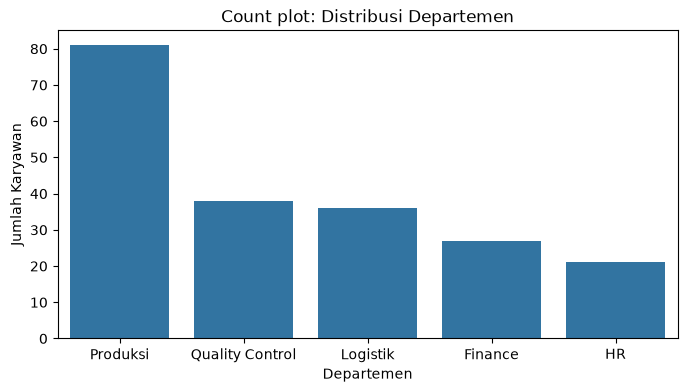

In [15]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x='departemen',
    order=df['departemen'].value_counts().index
)

plt.title("Count plot: Distribusi Departemen")
plt.xlabel("Departemen")
plt.ylabel("Jumlah Karyawan")
plt.show()


## 3.2 Absolute vs Relative Frequency

Memilih antara menampilkan frekuensi absolut (raw count) atau relatif (proporsi/persentase) bukan sekadar preferensi visual — keduanya menjawab pertanyaan yang berbeda:

* Frekuensi absolut cocok ketika skala jumlah observasi itu sendiri relevan — misalnya untuk mengetahui apakah suatu kategori memiliki cukup data untuk dianalisis lebih lanjut atau dilatih dalam model.
* Frekuensi relatif cocok ketika tujuan analisis adalah membandingkan proporsi, terutama saat membandingkan dua dataset atau dua periode waktu dengan total observasi yang berbeda.

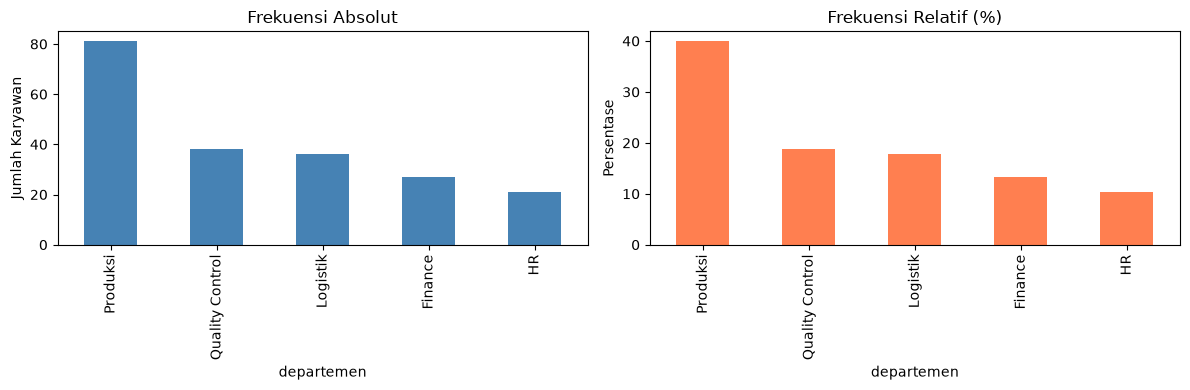

In [16]:
# Visualisasi berdampingan: frekuensi absolut vs relatif
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Frekuensi absolut (raw count)
df['departemen'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Frekuensi Absolut')
axes[0].set_ylabel('Jumlah Karyawan')

# Panel 2: Frekuensi relatif (dalam persentase)
(df['departemen'].value_counts(normalize=True) * 100).plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Frekuensi Relatif (%)')
axes[1].set_ylabel('Persentase')

plt.tight_layout()
plt.show()